In [2]:
print("done")

done


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns

# Base directory where the dataset is mounted
base_dir = "/kaggle/input/sicapv2"

# Check directory structure
for root, dirs, files in os.walk(base_dir):
    print(f"{root} -> {len(files)} files")


/kaggle/input/sicapv2 -> 0 files
/kaggle/input/sicapv2/SICAPv2 -> 0 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2 -> 2 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/images -> 18783 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition -> 0 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation -> 0 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation/Val3 -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation/Val4 -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation/Val2 -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation/Val1 -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Test -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/masks -> 18783 files


In [4]:
import os

image_dir = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/images"
print("Files in images dir:", os.listdir(image_dir)[:5])


Files in images dir: ['16B0006669_Block_Region_24_6_2_xini_14275_yini_13598.jpg', '18B0005230E_Block_Region_5_11_23_xini_38257_yini_96363.jpg', '18B0006621D_Block_Region_2_1_13_xini_21582_yini_66086.jpg', '18B0006177A_Block_Region_2_6_19_xini_51693_yini_147491.jpg', '16B0022612_Block_Region_1_20_12_xini_15667_yini_92428.jpg']


Total images found: 18783
✅ Found matching image + mask for: 16B0006694_Block_Region_1_32_2_xini_8143_yini_145334.jpg
Image shape: (512, 512, 3)
Mask shape: (512, 512)
Unique values in mask: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  30  32  34 168 169 171 172
 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190
 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208
 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226
 227 228 229 230 233]


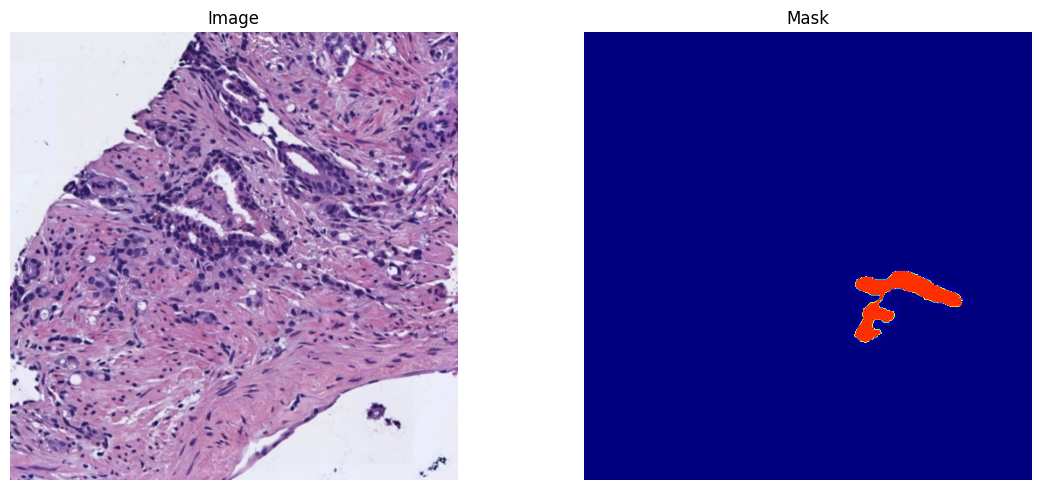

In [5]:
import random
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from glob import glob

# Correct image and mask directories
image_dir = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/images"
mask_dir = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/masks"

# Get list of image files
image_paths = glob(os.path.join(image_dir, "*.jpg"))
print(f"Total images found: {len(image_paths)}")

# Try loading image-mask pair
for _ in range(20):
    sample_image_path = random.choice(image_paths)
    filename = os.path.basename(sample_image_path)
    sample_mask_path = os.path.join(mask_dir, filename)  # No extension change now

    if os.path.exists(sample_mask_path):
        print("✅ Found matching image + mask for:", filename)
        break
else:
    raise FileNotFoundError("No matching masks found for any image.")

# Load image and mask
image = cv2.imread(sample_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

# Print some sanity info
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Unique values in mask:", np.unique(mask))

# Show image and mask
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='jet')
plt.title("Mask")
plt.axis("off")

plt.tight_layout()
plt.show()


In [6]:
import pandas as pd

# Path to Excel label file
xlsx_path = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/wsi_labels.xlsx"

# Read Excel
df = pd.read_excel(xlsx_path)

# Your GG logic
def gleason_to_gg(primary, secondary):
    total = primary + secondary
    if total == 7 and primary == 4:
        return "GG3"
    elif total == 8:
        return "GG4"
    elif total >= 9:
        return "GG5"
    else:
        return "NC"

df["GG"] = df.apply(lambda row: gleason_to_gg(row["Gleason_primary"], row["Gleason_secondary"]), axis=1)

print(df.head())
print(df["GG"].value_counts())


     slide_id  patient_id  Gleason_primary  Gleason_secondary   GG
0  16B0001851      667360                4                  5  GG5
1  16B0003388      325687                4                  4  GG4
2  16B0003394      747184                3                  3   NC
3  16B0006668       14107                5                  5  GG5
4  16B0006669       14107                5                  5  GG5
GG
NC     72
GG5    42
GG3    23
GG4    18
Name: count, dtype: int64


In [7]:
from glob import glob
import pandas as pd
import os

# Load GG labels
labels_df = pd.read_excel("/kaggle/input/sicapv2/SICAPv2/SICAPv2/wsi_labels.xlsx")
def gleason_to_gg(primary, secondary):
    total = primary + secondary
    if total == 7 and primary == 4:
        return "GG3"
    elif total == 8:
        return "GG4"
    elif total >= 9:
        return "GG5"
    else:
        return "NC"
labels_df["GG"] = labels_df.apply(lambda row: gleason_to_gg(row["Gleason_primary"], row["Gleason_secondary"]), axis=1)

# Create a dictionary for quick lookup
slideid_to_gg = dict(zip(labels_df["slide_id"].astype(str), labels_df["GG"]))

# Grab all patch image paths
patch_dir = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/images"
patch_paths = glob(os.path.join(patch_dir, "*.jpg"))

# Build dataframe with patch paths and labels
patch_data = []
for path in patch_paths:
    filename = os.path.basename(path)
    slide_id = filename.split("_")[0]
    if slide_id in slideid_to_gg:
        label = slideid_to_gg[slide_id]
        patch_data.append((path, label))

# Create final dataframe
patch_df = pd.DataFrame(patch_data, columns=["path", "label"])
print("Total labeled patches:", len(patch_df))
print(patch_df["label"].value_counts())
patch_df.head()


Total labeled patches: 18783
label
NC     7995
GG5    5654
GG3    3082
GG4    2052
Name: count, dtype: int64


,path,label
0,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,GG5
1,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,NC
2,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,GG3
3,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,GG5
4,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,NC


In [8]:
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

label_to_idx = {"NC": 0, "GG3": 1, "GG4": 2, "GG5": 3}

class PatchDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        label_str = self.df.loc[idx, "label"]
        label = label_to_idx[label_str]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label


In [ ]:
from sklearn.model_selection import train_test_split

# First split: train vs (val + test)
train_df, temp_df = train_test_split(
    patch_df, test_size=0.2, stratify=patch_df["label"], random_state=42)

# Second split: val vs test
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


In [9]:
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

label_to_idx = {"NC": 0, "GG3": 1, "GG4": 2, "GG5": 3}

class PatchDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        label_str = self.df.loc[idx, "label"]
        label = label_to_idx[label_str]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label


In [51]:
# Cell 1: Imports + Setup

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
from torchvision import models
import timm  # for EfficientNet + Swin Transformer
import os
import numpy as np
import random

# Set seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Checkpoint directory
checkpoint_dir = "/kaggle/working/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)


Using device: cuda


In [14]:

common_transform = transforms.Compose([
    transforms.Resize((299, 299)),    
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


In [15]:
label_to_idx = {"NC": 0, "GG3": 1, "GG4": 2, "GG5": 3}

class PatchDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        label_str = self.df.loc[idx, "label"]
        label = label_to_idx[label_str]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label


In [17]:
from sklearn.model_selection import train_test_split

# First split: train vs (val + test)
train_df, temp_df = train_test_split(
    patch_df, test_size=0.2, stratify=patch_df["label"], random_state=42)

# Second split: val vs test
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 15026 | Val: 1878 | Test: 1879


In [18]:
# Use the same transform for all
train_dataset = PatchDataset(train_df, transform=common_transform)
val_dataset = PatchDataset(val_df, transform=common_transform)
test_dataset = PatchDataset(test_df, transform=common_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("✅ All dataloaders are ready.")


✅ All dataloaders are ready.


In [19]:
# Cell 2: Dataset + Dataloaders

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Transform (keeping consistent with Inception/EfficientNet input)
common_transform = transforms.Compose([
    transforms.Resize((299, 299)),    
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)  # same as your previous training
])

# Label mapping
label_to_idx = {"NC": 0, "GG3": 1, "GG4": 2, "GG5": 3}

class PatchDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        label_str = self.df.loc[idx, "label"]
        label = label_to_idx[label_str]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label

# Build datasets
train_dataset = PatchDataset(train_df, transform=common_transform)
val_dataset   = PatchDataset(val_df,   transform=common_transform)
test_dataset  = PatchDataset(test_df,  transform=common_transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("✅ All dataloaders are ready.")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


✅ All dataloaders are ready.
Train: 15026 | Val: 1878 | Test: 1879


In [20]:
#  Feature Extractors (InceptionNet + Swin Transformer)

import torch
import torch.nn as nn
from torchvision import models
from timm import create_model

num_classes = 4  # NC, GG3, GG4, GG5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- InceptionNet ----------------
inception = models.inception_v3(weights="IMAGENET1K_V1")
inception.aux_logits = False
inception_fc_in = inception.fc.in_features
inception.fc = nn.Identity()   # remove classifier head

# ---------------- Swin Transformer ----------------
swin = create_model("swin_tiny_patch4_window7_224", pretrained=True)
swin_fc_in = swin.head.in_features
swin.head = nn.Identity()      # remove classifier head

# ---------------- Fusion Classifier ----------------
fusion_dim = inception_fc_in + swin_fc_in
classifier = nn.Sequential(
    nn.Linear(fusion_dim, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)

# Move to device
inception = inception.to(device)
swin = swin.to(device)
classifier = classifier.to(device)

print("✅ Feature extractors ready with fusion classifier on", device)
print(f"Inception features: {inception_fc_in}, Swin features: {swin_fc_in}, Fusion dim: {fusion_dim}")


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 194MB/s]  


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

✅ Feature extractors ready with fusion classifier on cuda
Inception features: 2048, Swin features: 768, Fusion dim: 2816


In [22]:
import torch.nn as nn

#  Fusion Classifier
class FusionClassifier(nn.Module):
    def __init__(self, in_dim=2816, hidden_dim=1024, num_classes=4):
        super(FusionClassifier, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)

fusion_model = FusionClassifier().cuda()
print("✅ Fusion classifier initialized on CUDA.")


✅ Fusion classifier initialized on CUDA.


In [75]:
class InceptionSwinFusion(nn.Module):
    def __init__(self, inception, swin, num_classes=4):
        super().__init__()
        self.inception = inception
        self.swin = swin
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)

        # Fusion feature dim
        incep_dim = 2048
        swin_dim = 768
        fused_dim = incep_dim + swin_dim

        # Attention Feature Aggregation
        self.afa = nn.Sequential(
            nn.Linear(fused_dim, fused_dim // 2),
            nn.ReLU(),
            nn.Linear(fused_dim // 2, fused_dim),
            nn.Sigmoid()
        )

        # Final classifier
        self.fc = nn.Linear(fused_dim, num_classes)

    def forward(self, x):
        # Inception features
        f_incep = self.inception(x)
        if f_incep.dim() > 2:
            f_incep = self.global_avg_pool(f_incep)
            f_incep = torch.flatten(f_incep, 1)

        # Swin features
        f_swin = self.swin(x)
        if f_swin.dim() > 2:
            f_swin = self.global_avg_pool(f_swin)
            f_swin = torch.flatten(f_swin, 1)

        # Concatenate
        fused = torch.cat([f_incep, f_swin], dim=1)

        # Attention Feature Aggregation
        fused = self.afa(fused)

        # Final classification
        out = self.fc(fused)
        return out


In [79]:
class InceptionSwinFusion(nn.Module):
    def __init__(self, inception, swin, fusion_head, num_classes=4):
        super().__init__()
        self.inception = inception
        self.swin = swin
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)  # pooling to flatten

        # Fusion head (can include AFA if you want)
        self.fusion_head = fusion_head
        self.num_classes = num_classes

    def forward(self, x):
        # ----- Inception -----
        x_incep = nn.functional.interpolate(x, size=(299, 299), mode="bilinear", align_corners=False)
        f_incep = self.inception(x_incep)
        if f_incep.dim() > 2:
            f_incep = self.global_avg_pool(f_incep)
            f_incep = torch.flatten(f_incep, 1)

        # ----- Swin -----
        x_swin = nn.functional.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        f_swin = self.swin(x_swin)
        if f_swin.dim() > 2:
            f_swin = self.global_avg_pool(f_swin)
            f_swin = torch.flatten(f_swin, 1)

        # ----- Concatenate -----
        fused = torch.cat([f_incep, f_swin], dim=1)

        # ----- Classification -----
        out = self.fusion_head(fused)
        return out

# Instantiate fusion model
fusion_model = InceptionSwinFusion(inception, swin, classifier).to(device)
print("✅ Fusion model ready on CUDA")


✅ Fusion model ready on CUDA


In [80]:
class AFAClassifier(nn.Module):
    def __init__(self, input_dim, num_classes=4):
        super().__init__()
        # Attention Feature Aggregation
        self.afa = nn.Sequential(
            nn.Linear(input_dim, input_dim // 2),
            nn.ReLU(),
            nn.Linear(input_dim // 2, input_dim),
            nn.Sigmoid()
        )
        # Final classifier
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        # x = concatenated features from Inception + Swin
        x = self.afa(x)  # attention modulation
        out = self.fc(x)
        return out


In [86]:
class IncepSwinAFA(nn.Module):
    def __init__(self, inception, swin, afa_classifier):
        super().__init__()
        self.inception = inception
        self.swin = swin
        self.afa_classifier = afa_classifier
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)

        # Freeze backbones if you only want to train AFA
        for param in self.inception.parameters():
            param.requires_grad = False
        for param in self.swin.parameters():
            param.requires_grad = False

    def forward(self, x):
        # ----- Inception features (299x299) -----
        x_incep = nn.functional.interpolate(x, size=(299, 299), mode="bilinear", align_corners=False)
        f_incep = self.inception(x_incep)
        if f_incep.dim() > 2:
            f_incep = self.global_avg_pool(f_incep)
            f_incep = torch.flatten(f_incep, 1)  # [B, 2048]

        # ----- Swin features (224x224) -----
        x_swin = nn.functional.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        f_swin = self.swin(x_swin)
        if f_swin.dim() > 2:
            f_swin = self.global_avg_pool(f_swin)
            f_swin = torch.flatten(f_swin, 1)  # [B, 768]

        # ----- Concatenate features -----
        fused_features = torch.cat([f_incep, f_swin], dim=1)  # [B, 2816]

        # ----- Pass through AFA classifier -----
        out = self.afa_classifier(fused_features)
        return out


In [88]:
# Wrap feature extractors + AFA classifier
model = IncepSwinAFA(inception, swin, fusion_model).to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer (only AFA classifier params will be updated)
import torch.optim as optim
optimizer = optim.Adam(model.afa_classifier.parameters(), lr=1e-4, weight_decay=1e-5)

print("✅ Model, criterion, and optimizer ready for training.")


✅ Model, criterion, and optimizer ready for training.


In [98]:
import torchvision.models as models
import torch.nn as nn

# Load InceptionV3 with pretrained weights
inception = models.inception_v3(weights="IMAGENET1K_V1")  # aux_logits=True forced internally

# Turn off aux_logits manually
inception.aux_logits = False
inception.AuxLogits = None  # remove the auxiliary classifier

# Remove the final fc classifier
inception.fc = nn.Identity()

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
inception = inception.to(device)

print("✅ InceptionV3 ready without auxiliary head")


✅ InceptionV3 ready without auxiliary head


In [100]:
from torchvision import models
import torch.nn as nn

# Load with default weights (aux_logits=True)
inception = models.inception_v3(weights="IMAGENET1K_V1")  

# Turn off auxiliary classifier manually
inception.aux_logits = False
inception.AuxLogits = None   # remove the auxiliary head object

# Replace main classifier with Identity
inception.fc = nn.Identity()


In [101]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models
import timm
from torch.utils.data import DataLoader, Dataset
from PIL import Image

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------- Dataset ----------------
class PatchDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_to_idx = {"NC":0, "GG3":1, "GG4":2, "GG5":3}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.loc[idx, "path"]
        label_str = self.df.loc[idx, "label"]
        label = self.label_to_idx[label_str]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# ---------------- Transforms ----------------
train_transform = transforms.Compose([
    transforms.Resize((299,299)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ---------------- DataLoaders ----------------
train_dataset = PatchDataset(train_df, transform=train_transform)
val_dataset   = PatchDataset(val_df, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# ---------------- Backbones ----------------
# Load Inception with pretrained weights (cannot set aux_logits=False in constructor anymore)
inception = models.inception_v3(weights="IMAGENET1K_V1")
inception.aux_logits = False
inception.AuxLogits = None      # remove auxiliary head
inception.fc = nn.Identity()    # remove classifier
inception = inception.to(device)
incep_dim = 2048

swin = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True)
swin.head = nn.Identity()
swin = swin.to(device)
swin_dim = 768

# ---------------- Classifier ----------------
class AFAClassifier(nn.Module):
    def __init__(self, input_dim, num_classes=4):
        super().__init__()
        self.afa = nn.Sequential(
            nn.Linear(input_dim, input_dim//2),
            nn.ReLU(),
            nn.Linear(input_dim//2, input_dim),
            nn.Sigmoid()
        )
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        x = self.afa(x)
        return self.fc(x)

# ---------------- Fusion Model ----------------
class IncepSwinAFA(nn.Module):
    def __init__(self, inception, swin, num_classes=4):
        super().__init__()
        self.inception = inception
        self.swin = swin

        # Freeze backbones
        for param in self.inception.parameters():
            param.requires_grad = False
        for param in self.swin.parameters():
            param.requires_grad = False

        # Determine fused feature dimension dynamically
        self.pool = nn.AdaptiveAvgPool2d(1)
        with torch.no_grad():
            dummy = torch.randn(1,3,299,299).to(device)
            f_incep = self.inception(dummy)
            if f_incep.dim() > 2:
                f_incep = self.pool(f_incep)
                f_incep = torch.flatten(f_incep, 1)
            f_swin = nn.functional.interpolate(dummy, size=(224,224), mode="bilinear", align_corners=False)
            f_swin = self.swin(f_swin)
            if f_swin.dim() > 2:
                f_swin = self.pool(f_swin)
                f_swin = torch.flatten(f_swin, 1)
            fused_dim = f_incep.size(1) + f_swin.size(1)

        self.classifier = AFAClassifier(fused_dim, num_classes)

    def forward(self, x):
        x = x.to(next(self.parameters()).device)

        # Inception features
        x_incep = nn.functional.interpolate(x, size=(299,299), mode="bilinear", align_corners=False)
        f_incep = self.inception(x_incep)
        if f_incep.dim() > 2:
            f_incep = self.pool(f_incep)
            f_incep = torch.flatten(f_incep, 1)

        # Swin features
        x_swin = nn.functional.interpolate(x, size=(224,224), mode="bilinear", align_corners=False)
        f_swin = self.swin(x_swin)
        if f_swin.dim() > 2:
            f_swin = self.pool(f_swin)
            f_swin = torch.flatten(f_swin, 1)

        # Concatenate + classify
        fused = torch.cat([f_incep, f_swin], dim=1)
        return self.classifier(fused)

# ---------------- Instantiate ----------------
model = IncepSwinAFA(inception, swin).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4, weight_decay=1e-5)

print("✅ Model ready for training.")


Using device: cuda
✅ Model ready for training.


In [102]:
# Grab a single batch from train_loader
images, labels = next(iter(train_loader))

# Print shapes
print("Images shape:", images.shape)  # should be [B, 3, H, W]
print("Labels shape:", labels.shape)  # should be [B]

# Sanity check on pixel range
print("Image min/max:", images.min().item(), images.max().item())
print("Label unique values:", labels.unique())


Images shape: torch.Size([32, 3, 299, 299])
Labels shape: torch.Size([32])
Image min/max: -0.9450980424880981 1.0
Label unique values: tensor([0, 1, 2, 3])


In [104]:
# Unfreeze last few layers of Inception and Swin
for name, param in inception.named_parameters():
    if "Mixed_7c" in name or "Conv2d_4a_3x3" in name:  # last layers
        param.requires_grad = True

for name, param in swin.named_parameters():
    if "layers.3" in name:  # last Swin stage
        param.requires_grad = True


In [105]:
optimizer = optim.Adam([
    {'params': model.inception.parameters(), 'lr': 1e-5},
    {'params': model.swin.parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-4}
], weight_decay=1e-5)


In [106]:
train_transform = transforms.Compose([
    transforms.Resize((299,299)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


In [110]:
import os
from tqdm import tqdm
import torch
from torch.cuda.amp import autocast, GradScaler

# ---------------- Setup ----------------
num_epochs = 10
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
best_acc = 0.0
scaler = GradScaler()  # for mixed precision

# Optional: LR scheduler (uncomment if needed)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

# ---------------- Training Loop ----------------
for epoch in range(1, num_epochs+1):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Training Epoch {epoch}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        with autocast():  # mixed precision
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        running_corrects += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total

    # ---------------- Validation ----------------
    model.eval()
    val_loss = 0.0
    val_corrects = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Validation Epoch {epoch}"):
            images, labels = images.to(device), labels.to(device)
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_corrects += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_epoch_loss = val_loss / val_total
    val_epoch_acc = val_corrects / val_total

    print(f"\nEpoch [{epoch}/{num_epochs}] "
          f"Train Loss: {epoch_loss:.4f} Train Acc: {epoch_acc:.4f} "
          f"Val Loss: {val_epoch_loss:.4f} Val Acc: {val_epoch_acc:.4f}")

    # ---------------- Save checkpoints ----------------
    epoch_ckpt_path = os.path.join(checkpoint_dir, f"epoch_{epoch}.pth")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': epoch_loss,
        'train_acc': epoch_acc,
        'val_loss': val_epoch_loss,
        'val_acc': val_epoch_acc
    }, epoch_ckpt_path)

    # Save best model
    if val_epoch_acc > best_acc:
        best_acc = val_epoch_acc
        best_ckpt_path = os.path.join(checkpoint_dir, "best_model.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': epoch_loss,
            'train_acc': epoch_acc,
            'val_loss': val_epoch_loss,
            'val_acc': val_epoch_acc
        }, best_ckpt_path)
        print(f"💾 Best model updated at epoch {epoch} with val_acc {best_acc:.4f}")

    # scheduler.step()  # uncomment if using a scheduler


/tmp/ipykernel_36/3166168417.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # for mixed precision
Training Epoch 1:   0%|          | 0/470 [00:00<?, ?it/s]/tmp/ipykernel_36/3166168417.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # mixed precision
Validation Epoch 1:   0%|          | 0/59 [00:00<?, ?it/s]/tmp/ipykernel_36/3166168417.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation Epoch 1: 100%|██████████| 59/59 [00:09<00:00,  6.13it/s]



Epoch [1/10] Train Loss: 0.9656 Train Acc: 0.6083 Val Loss: 0.9024 Val Acc: 0.6342
💾 Best model updated at epoch 1 with val_acc 0.6342


Validation Epoch 2: 100%|██████████| 59/59 [00:09<00:00,  6.19it/s]



Epoch [2/10] Train Loss: 0.8785 Train Acc: 0.6471 Val Loss: 0.8537 Val Acc: 0.6491
💾 Best model updated at epoch 2 with val_acc 0.6491


Validation Epoch 3: 100%|██████████| 59/59 [00:09<00:00,  6.16it/s]


...


Epoch [8/10] Train Loss: 0.4459 Train Acc: 0.8280 Val Loss: 0.6538 Val Acc: 0.7487
💾 Best model updated at epoch 8 with val_acc 0.7487


Validation Epoch 9: 100%|██████████| 59/59 [00:09<00:00,  6.14it/s]



Epoch [9/10] Train Loss: 0.3861 Train Acc: 0.8518 Val Loss: 0.6638 Val Acc: 0.7588
💾 Best model updated at epoch 9 with val_acc 0.7588


Validation Epoch 10: 100%|██████████| 59/59 [00:09<00:00,  6.14it/s]



Epoch [10/10] Train Loss: 0.3450 Train Acc: 0.8692 Val Loss: 0.6472 Val Acc: 0.7599
💾 Best model updated at epoch 10 with val_acc 0.7599


In [111]:
# ---------------- Setup ----------------
num_extra_epochs = 5
checkpoint_dir = "./checkpoints"

# Load best model
best_ckpt_path = os.path.join(checkpoint_dir, "best_model.pth")
checkpoint = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch'] + 1
best_acc = checkpoint['val_acc']

print(f"✅ Loaded best model from epoch {checkpoint['epoch']} with val_acc {best_acc:.4f}")

# ---------------- Training Loop ----------------
for epoch in range(start_epoch, start_epoch + num_extra_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Training Epoch {epoch}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        running_corrects += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total

    # ---------------- Validation ----------------
    model.eval()
    val_loss = 0.0
    val_corrects = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Validation Epoch {epoch}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_corrects += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_epoch_loss = val_loss / val_total
    val_epoch_acc = val_corrects / val_total

    print(f"\nEpoch [{epoch}/{start_epoch + num_extra_epochs - 1}] "
          f"Train Loss: {epoch_loss:.4f} Train Acc: {epoch_acc:.4f} "
          f"Val Loss: {val_epoch_loss:.4f} Val Acc: {val_epoch_acc:.4f}")

    # ---------------- Save checkpoints ----------------
    epoch_ckpt_path = os.path.join(checkpoint_dir, f"epoch_{epoch}.pth")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': epoch_loss,
        'train_acc': epoch_acc,
        'val_loss': val_epoch_loss,
        'val_acc': val_epoch_acc
    }, epoch_ckpt_path)

    # Save best model
    if val_epoch_acc > best_acc:
        best_acc = val_epoch_acc
        best_ckpt_path = os.path.join(checkpoint_dir, "best_model.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': epoch_loss,
            'train_acc': epoch_acc,
            'val_loss': val_epoch_loss,
            'val_acc': val_epoch_acc
        }, best_ckpt_path)
        print(f"💾 Best model updated at epoch {epoch} with val_acc {best_acc:.4f}")


✅ Loaded best model from epoch 10 with val_acc 0.7599


Validation Epoch 11: 100%|██████████| 59/59 [00:18<00:00,  3.23it/s]



Epoch [11/15] Train Loss: 0.3025 Train Acc: 0.8881 Val Loss: 0.6383 Val Acc: 0.7726
💾 Best model updated at epoch 11 with val_acc 0.7726


Validation Epoch 12: 100%|██████████| 59/59 [00:18<00:00,  3.24it/s]



Epoch [12/15] Train Loss: 0.2606 Train Acc: 0.9004 Val Loss: 0.6673 Val Acc: 0.7753
💾 Best model updated at epoch 12 with val_acc 0.7753


...


Epoch [13/15] Train Loss: 0.2368 Train Acc: 0.9116 Val Loss: 0.6496 Val Acc: 0.7780
💾 Best model updated at epoch 13 with val_acc 0.7780


Validation Epoch 14: 100%|██████████| 59/59 [00:18<00:00,  3.25it/s]



Epoch [14/15] Train Loss: 0.2095 Train Acc: 0.9223 Val Loss: 0.6431 Val Acc: 0.7918
💾 Best model updated at epoch 14 with val_acc 0.7918


Validation Epoch 15: 100%|██████████| 59/59 [00:18<00:00,  3.22it/s]



Epoch [15/15] Train Loss: 0.1913 Train Acc: 0.9293 Val Loss: 0.6603 Val Acc: 0.7817


In [112]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# ---------------- Setup ----------------
test_dataset = PatchDataset(test_df, transform=train_transform)  # assuming test_df exists
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Load best model
best_ckpt_path = "./checkpoints/best_model.pth"
checkpoint = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ---------------- Metrics ----------------
accuracy = (all_preds == all_labels).mean()
print(f"Test Accuracy: {accuracy:.4f}")

# Optional: Confusion Matrix and Classification Report
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

report = classification_report(all_labels, all_preds, target_names=["NC","GG3","GG4","GG5"])
print("\nClassification Report:\n", report)


Test Accuracy: 0.5067
Confusion Matrix:
 [[396  34  24 346]
 [ 75  28  10 195]
 [ 22  10  15 158]
 [ 35   7  11 513]]

Classification Report:
               precision    recall  f1-score   support

          NC       0.75      0.49      0.60       800
         GG3       0.35      0.09      0.14       308
         GG4       0.25      0.07      0.11       205
         GG5       0.42      0.91      0.58       566

    accuracy                           0.51      1879
   macro avg       0.44      0.39      0.36      1879
weighted avg       0.53      0.51      0.46      1879



In [113]:
import os
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------- Checkpoints ----------------
finetune_checkpoint_dir = "./checkpoints_finetune_unfrozen"
os.makedirs(finetune_checkpoint_dir, exist_ok=True)
best_acc = 0.0
num_epochs = 10

# ---------------- Optimizer with different LR ----------------
optimizer = optim.Adam([
    {'params': [p for p in inception.parameters() if p.requires_grad], 'lr': 1e-5},
    {'params': [p for p in swin.parameters() if p.requires_grad], 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-4}
], weight_decay=1e-5)

criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

# ---------------- Fine-tuning Loop ----------------
for epoch in range(1, num_epochs+1):
    model.train()
    running_loss, running_corrects, total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"FT Train Epoch {epoch}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_corrects += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total

    # ---------------- Validation ----------------
    model.eval()
    val_loss, val_corrects, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"FT Val Epoch {epoch}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_corrects += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_epoch_loss = val_loss / val_total
    val_epoch_acc = val_corrects / val_total

    print(f"\nFT Epoch [{epoch}/{num_epochs}] "
          f"Train Loss: {epoch_loss:.4f} Train Acc: {epoch_acc:.4f} "
          f"Val Loss: {val_epoch_loss:.4f} Val Acc: {val_epoch_acc:.4f}")

    # ---------------- Save checkpoints ----------------
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': epoch_loss,
        'train_acc': epoch_acc,
        'val_loss': val_epoch_loss,
        'val_acc': val_epoch_acc
    }, os.path.join(finetune_checkpoint_dir, f"ft_epoch_{epoch}.pth"))

    if val_epoch_acc > best_acc:
        best_acc = val_epoch_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': epoch_loss,
            'train_acc': epoch_acc,
            'val_loss': val_epoch_loss,
            'val_acc': val_epoch_acc
        }, os.path.join(finetune_checkpoint_dir, "ft_best_model.pth"))
        print(f"💾 Best FT model updated at epoch {epoch} with val_acc {best_acc:.4f}")

    scheduler.step()


Using device: cuda


FT Val Epoch 1: 100%|██████████| 59/59 [00:18<00:00,  3.25it/s]



FT Epoch [1/10] Train Loss: 0.1893 Train Acc: 0.9303 Val Loss: 0.7027 Val Acc: 0.7859
💾 Best FT model updated at epoch 1 with val_acc 0.7859


FT Val Epoch 2: 100%|██████████| 59/59 [00:18<00:00,  3.23it/s]



FT Epoch [2/10] Train Loss: 0.1684 Train Acc: 0.9384 Val Loss: 0.7440 Val Acc: 0.7859


...


FT Epoch [8/10] Train Loss: 0.0907 Train Acc: 0.9690 Val Loss: 0.7203 Val Acc: 0.8024


FT Val Epoch 9: 100%|██████████| 59/59 [00:18<00:00,  3.26it/s]



FT Epoch [9/10] Train Loss: 0.0774 Train Acc: 0.9725 Val Loss: 0.7213 Val Acc: 0.8024


FT Train Epoch 10:  36%|███▌      | 170/470 [01:28<02:35,  1.92it/s]


KeyboardInterrupt: 

Using device: cuda
Loaded best FT model from epoch 7 with val_acc 0.8067
Test/Validation Accuracy: 0.8067
Confusion Matrix:
 [[701  61   3  34]
 [ 60 217   9  23]
 [ 26  14 122  43]
 [ 41  22  27 475]]


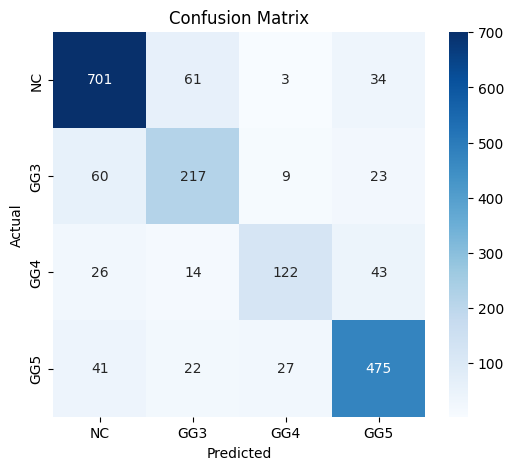

              precision    recall  f1-score   support

          NC       0.85      0.88      0.86       799
         GG3       0.69      0.70      0.70       309
         GG4       0.76      0.60      0.67       205
         GG5       0.83      0.84      0.83       565

    accuracy                           0.81      1878
   macro avg       0.78      0.75      0.76      1878
weighted avg       0.81      0.81      0.80      1878



In [114]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------- Load best fine-tuned model ----------------
checkpoint_path = "./checkpoints_finetune_unfrozen/ft_best_model.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()
print(f"Loaded best FT model from epoch {checkpoint['epoch']} with val_acc {checkpoint['val_acc']:.4f}")

# ---------------- Testing ----------------
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:  # use val_loader or test_loader
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# ---------------- Accuracy ----------------
accuracy = np.mean(all_preds == all_labels)
print(f"Test/Validation Accuracy: {accuracy:.4f}")

# ---------------- Confusion Matrix ----------------
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

# Optional: Pretty heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["NC","GG3","GG4","GG5"], yticklabels=["NC","GG3","GG4","GG5"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ---------------- Classification Report ----------------
report = classification_report(all_labels, all_preds, target_names=["NC","GG3","GG4","GG5"])
print(report)


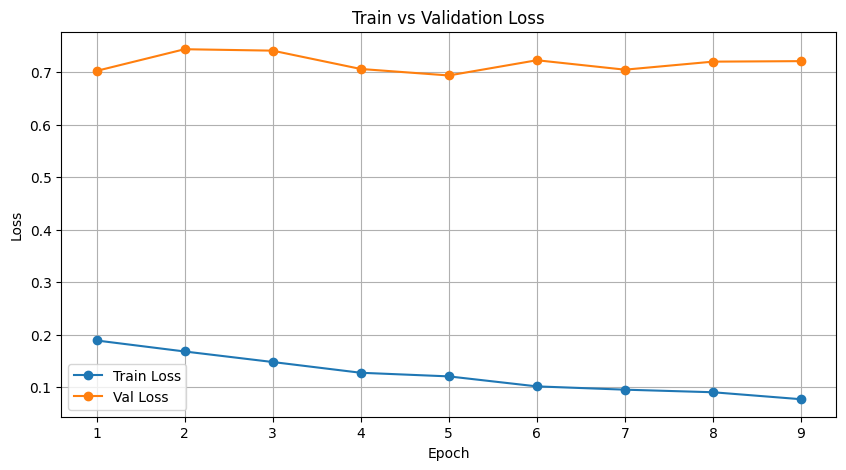

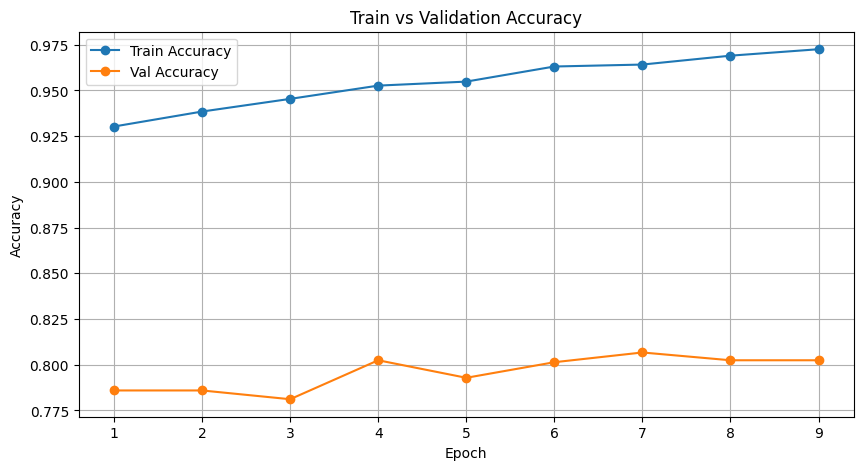

In [121]:
import os
import torch
import matplotlib.pyplot as plt

checkpoint_dir = "./checkpoints_finetune_unfrozen"
ckpt_files = sorted([f for f in os.listdir(checkpoint_dir) if f.startswith("ft_epoch") and f.endswith(".pth")])

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for f in ckpt_files:
    path = os.path.join(checkpoint_dir, f)
    ckpt = torch.load(path, map_location="cpu")
    train_losses.append(ckpt['train_loss'])
    val_losses.append(ckpt['val_loss'])
    train_accs.append(ckpt['train_acc'])
    val_accs.append(ckpt['val_acc'])

epochs = range(1, len(ckpt_files)+1)

# ---------------- Loss Plot ----------------
plt.figure(figsize=(10,5))
plt.plot(epochs, train_losses, label="Train Loss", marker='o')
plt.plot(epochs, val_losses, label="Val Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ---------------- Accuracy Plot ----------------
plt.figure(figsize=(10,5))
plt.plot(epochs, train_accs, label="Train Accuracy", marker='o')
plt.plot(epochs, val_accs, label="Val Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [117]:
from tqdm import tqdm  # plain tqdm works better on Kaggle

for epoch in range(1, num_epochs+1):
    # ---------------- Training ----------------
    model.train()
    running_loss, running_corrects, total = 0.0, 0, 0
    train_iter = tqdm(train_loader, desc=f"FT Train Epoch {epoch}")
    for images, labels in train_iter:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_corrects += (preds == labels).sum().item()
        total += labels.size(0)

        train_iter.set_postfix(loss=running_loss/total, acc=running_corrects/total)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total

    # ---------------- Validation ----------------
    model.eval()
    val_loss, val_corrects, val_total = 0.0, 0, 0
    val_iter = tqdm(val_loader, desc=f"FT Val Epoch {epoch}")
    with torch.no_grad():
        for images, labels in val_iter:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_corrects += (preds == labels).sum().item()
            val_total += labels.size(0)

            val_iter.set_postfix(val_loss=val_loss/val_total, val_acc=val_corrects/val_total)

    val_epoch_loss = val_loss / val_total
    val_epoch_acc = val_corrects / val_total

    print(f"\nFT Epoch [{epoch}/{num_epochs}] "
          f"Train Loss: {epoch_loss:.4f} Train Acc: {epoch_acc:.4f} "
          f"Val Loss: {val_epoch_loss:.4f} Val Acc: {val_epoch_acc:.4f}")

    # ---------------- Save checkpoints ----------------
    epoch_ckpt_path = os.path.join(ft_checkpoint_dir, f"ft_full_epoch_{epoch}.pth")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': epoch_loss,
        'train_acc': epoch_acc,
        'val_loss': val_epoch_loss,
        'val_acc': val_epoch_acc
    }, epoch_ckpt_path)

    if val_epoch_acc > best_acc:
        best_acc = val_epoch_acc
        best_ckpt_path = os.path.join(ft_checkpoint_dir, "ft_full_best_model.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': epoch_loss,
            'train_acc': epoch_acc,
            'val_loss': val_epoch_loss,
            'val_acc': val_epoch_acc
        }, best_ckpt_path)
        print(f"💾 Best FT model updated at epoch {epoch} with val_acc {best_acc:.4f}")

    scheduler.step(val_epoch_loss)


FT Val Epoch 1: 100%|██████████| 59/59 [00:18<00:00,  3.23it/s, val_acc=0.723, val_loss=0.7]  



FT Epoch [1/10] Train Loss: 0.8418 Train Acc: 0.6664 Val Loss: 0.7000 Val Acc: 0.7226
💾 Best FT model updated at epoch 1 with val_acc 0.7226


FT Val Epoch 2: 100%|██████████| 59/59 [00:18<00:00,  3.23it/s, val_acc=0.732, val_loss=0.69] 



FT Epoch [2/10] Train Loss: 0.8192 Train Acc: 0.6772 Val Loss: 0.6895 Val Acc: 0.7316
💾 Best FT model updated at epoch 2 with val_acc 0.7316


FT Val Epoch 3: 100%|██████████| 59/59 [00:18<00:00,  3.23it/s, val_acc=0.729, val_loss=0.69] 


...


FT Epoch [5/10] Train Loss: 0.7709 Train Acc: 0.6967 Val Loss: 0.6927 Val Acc: 0.7338


FT Val Epoch 6: 100%|██████████| 59/59 [00:18<00:00,  3.23it/s, val_acc=0.732, val_loss=0.691]



FT Epoch [6/10] Train Loss: 0.7675 Train Acc: 0.7022 Val Loss: 0.6911 Val Acc: 0.7316


FT Val Epoch 7:  69%|██████▉   | 41/59 [00:13<00:05,  3.10it/s, val_acc=0.749, val_loss=0.658]


KeyboardInterrupt: 

In [118]:
import os
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------- Checkpoints ----------------
ft_unfrozen_checkpoint_dir = "./checkpoints_finetune_unfrozen_v2"
os.makedirs(ft_unfrozen_checkpoint_dir, exist_ok=True)
best_acc = 0.0
num_epochs = 15

# ---------------- Data Augmentation ----------------
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(299, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset.transform = train_transform
val_dataset.transform = val_transform

# ---------------- Gradual Unfreezing ----------------
# Freeze all first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last stage of Swin + last Inception block + classifier
for name, param in model.swin.named_parameters():
    if "layers.3" in name:  # last stage
        param.requires_grad = True

for name, param in model.inception.named_parameters():
    if "Mixed_7c" in name:  # last inception block
        param.requires_grad = True

# Unfreeze classifier
for param in model.classifier.parameters():
    param.requires_grad = True

# ---------------- Add Dropout to Classifier ----------------
if not hasattr(model.classifier, "dropout_added"):
    class DropoutAFAClassifier(nn.Module):
        def __init__(self, original):
            super().__init__()
            self.afa = nn.Sequential(
                nn.Linear(original.afa[0].in_features, original.afa[0].out_features),
                nn.ReLU(),
                nn.Dropout(0.3),  # added dropout
                nn.Linear(original.afa[2].in_features, original.afa[2].out_features),
                nn.Sigmoid()
            )
            self.fc = original.fc
        def forward(self, x):
            x = self.afa(x)
            return self.fc(x)
    model.classifier = DropoutAFAClassifier(model.classifier).to(device)
    model.classifier.dropout_added = True

# ---------------- Optimizer with Layer-wise LR ----------------
optimizer = optim.Adam([
    {'params': [p for p in model.swin.parameters() if p.requires_grad], 'lr': 5e-6},
    {'params': [p for p in model.inception.parameters() if p.requires_grad], 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-4}
], weight_decay=1e-5)

# ---------------- Scheduler ----------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ---------------- Fine-tune Loop ----------------
for epoch in range(1, num_epochs+1):
    # ---------------- Training ----------------
    model.train()
    running_loss, running_corrects, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"FT Train Epoch {epoch}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_corrects += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total

    # ---------------- Validation ----------------
    model.eval()
    val_loss, val_corrects, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"FT Val Epoch {epoch}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_corrects += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_epoch_loss = val_loss / val_total
    val_epoch_acc = val_corrects / val_total

    print(f"\nFT Epoch [{epoch}/{num_epochs}] "
          f"Train Loss: {epoch_loss:.4f} Train Acc: {epoch_acc:.4f} "
          f"Val Loss: {val_epoch_loss:.4f} Val Acc: {val_epoch_acc:.4f}")

    # ---------------- Save checkpoints ----------------
    epoch_ckpt_path = os.path.join(ft_unfrozen_checkpoint_dir, f"ft_unfrozen_epoch_{epoch}.pth")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': epoch_loss,
        'train_acc': epoch_acc,
        'val_loss': val_epoch_loss,
        'val_acc': val_epoch_acc
    }, epoch_ckpt_path)

    if val_epoch_acc > best_acc:
        best_acc = val_epoch_acc
        best_ckpt_path = os.path.join(ft_unfrozen_checkpoint_dir, "ft_unfrozen_best_model.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': epoch_loss,
            'train_acc': epoch_acc,
            'val_loss': val_epoch_loss,
            'val_acc': val_epoch_acc
        }, best_ckpt_path)
        print(f"💾 Best FT model updated at epoch {epoch} with val_acc {best_acc:.4f}")

    # Step scheduler
    scheduler.step(val_epoch_loss)


Using device: cuda


FT Val Epoch 1: 100%|██████████| 59/59 [00:18<00:00,  3.25it/s]



FT Epoch [1/15] Train Loss: 1.0808 Train Acc: 0.5966 Val Loss: 0.9078 Val Acc: 0.6949
💾 Best FT model updated at epoch 1 with val_acc 0.6949


FT Val Epoch 2: 100%|██████████| 59/59 [00:18<00:00,  3.24it/s]



FT Epoch [2/15] Train Loss: 0.9956 Train Acc: 0.6509 Val Loss: 0.8602 Val Acc: 0.7247
💾 Best FT model updated at epoch 2 with val_acc 0.7247


...

FT Val Epoch 13: 100%|██████████| 59/59 [00:18<00:00,  3.23it/s]



FT Epoch [13/15] Train Loss: 0.9044 Train Acc: 0.7028 Val Loss: 0.8193 Val Acc: 0.7556


FT Val Epoch 14: 100%|██████████| 59/59 [00:18<00:00,  3.26it/s]



FT Epoch [14/15] Train Loss: 0.8934 Train Acc: 0.7090 Val Loss: 0.8024 Val Acc: 0.7630


RuntimeError: [enforce fail at inline_container.cc:626] . unexpected pos 51083712 vs 51083608

In [119]:
import os
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------- Load Best Checkpoint ----------------
best_ckpt_path = "./checkpoints_finetune_unfrozen_v2/ft_unfrozen_best_model.pth"
checkpoint = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

# ---------------- Checkpoints ----------------
continued_checkpoint_dir = "./checkpoints_finetune_unfrozen_continued"
os.makedirs(continued_checkpoint_dir, exist_ok=True)
best_acc = checkpoint['val_acc']
num_epochs = 10  # continue for 10 more epochs

# ---------------- Data Augmentation ----------------
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(299, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset.transform = train_transform
val_dataset.transform = val_transform

# ---------------- Optimizer ----------------
optimizer = optim.Adam([
    {'params': [p for p in model.swin.parameters() if p.requires_grad], 'lr': 5e-6},
    {'params': [p for p in model.inception.parameters() if p.requires_grad], 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-4}
], weight_decay=1e-5)

# ---------------- Scheduler ----------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ---------------- Fine-tune Loop ----------------
for epoch in range(1, num_epochs+1):
    # ---------------- Training ----------------
    model.train()
    running_loss, running_corrects, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Continued FT Train Epoch {epoch}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_corrects += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total

    # ---------------- Validation ----------------
    model.eval()
    val_loss, val_corrects, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Continued FT Val Epoch {epoch}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_corrects += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_epoch_loss = val_loss / val_total
    val_epoch_acc = val_corrects / val_total

    print(f"\nContinued FT Epoch [{epoch}/{num_epochs}] "
          f"Train Loss: {epoch_loss:.4f} Train Acc: {epoch_acc:.4f} "
          f"Val Loss: {val_epoch_loss:.4f} Val Acc: {val_epoch_acc:.4f}")

    # ---------------- Save checkpoints ----------------
    epoch_ckpt_path = os.path.join(continued_checkpoint_dir, f"continued_ft_epoch_{epoch}.pth")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': epoch_loss,
        'train_acc': epoch_acc,
        'val_loss': val_epoch_loss,
        'val_acc': val_epoch_acc
    }, epoch_ckpt_path)

    if val_epoch_acc > best_acc:
        best_acc = val_epoch_acc
        best_ckpt_path = os.path.join(continued_checkpoint_dir, "continued_ft_best_model.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': epoch_loss,
            'train_acc': epoch_acc,
            'val_loss': val_epoch_loss,
            'val_acc': val_epoch_acc
        }, best_ckpt_path)
        print(f"💾 Best continued FT model updated at epoch {epoch} with val_acc {best_acc:.4f}")

    # Step scheduler
    scheduler.step(val_epoch_loss)


Using device: cuda


OSError: [Errno 28] No space left on device: './checkpoints_finetune_unfrozen_continued'